In [9]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import (
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

from sklearn.model_selection import GridSearchCV, StratifiedKFold

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)


columns = [
    "id",
    "diagnosis",

    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "smoothness_mean",
    "compactness_mean",
    "concavity_mean",
    "concave_points_mean",
    "symmetry_mean",
    "fractal_dimension_mean",

    "radius_se",
    "texture_se",
    "perimeter_se",
    "area_se",
    "smoothness_se",
    "compactness_se",
    "concavity_se",
    "concave_points_se",
    "symmetry_se",
    "fractal_dimension_se",

    "radius_worst",
    "texture_worst",
    "perimeter_worst",
    "area_worst",
    "smoothness_worst",
    "compactness_worst",
    "concavity_worst",
    "concave_points_worst",
    "symmetry_worst",
    "fractal_dimension_worst"
]

df = pd.read_csv(
    "wdbc.data",
    header=None,
    names=columns
)




print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nDataset Information:")
print(df.info())

print("\nClass Distribution:")
print(df["diagnosis"].value_counts())

print("\nMissing Values:")
print(df.isnull().sum().sum())

First 5 rows:
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave_points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_w

Dataset Shape: (569, 32)

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    flo

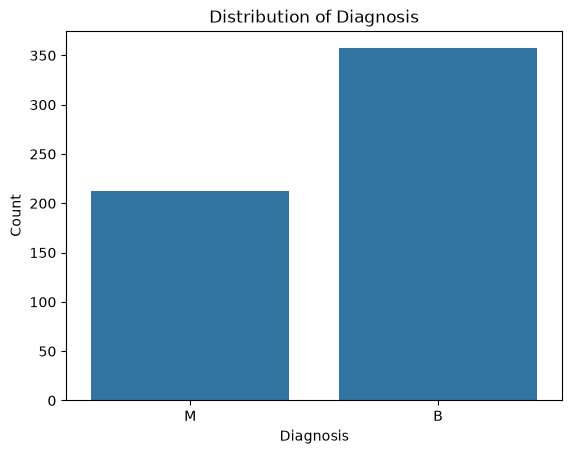


Training Data Shape: (455, 30)
Testing Data Shape: (114, 30)


In [2]:
# ==============================
# CELL 2: EDA + PREPROCESSING
# ==============================

# 1. Check dataset information
print("Dataset Shape:", df.shape)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())


# 2. Check missing values
print("\nMissing Values:")
print(df.isnull().sum().sum())


# 3. Check class distribution
print("\nDiagnosis Distribution:")
print(df["diagnosis"].value_counts())


# 4. Visualize class distribution
sns.countplot(x="diagnosis", data=df)

plt.title("Distribution of Diagnosis")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()


# 5. Separate input features and target
# Remove ID because it is not a useful ML feature
X = df.drop(["id", "diagnosis"], axis=1)

# Target variable
y = df["diagnosis"]


# 6. Convert target labels
# B = 0 (Benign)
# M = 1 (Malignant)

y = y.map({"B": 0, "M": 1})


# 7. Split dataset into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# 8. Display split sizes
print("\nTraining Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

In [3]:
# ==============================
# CELL 3: BAGGING
# ==============================

# Base estimator
dt = DecisionTreeClassifier(random_state=42)

# Bagging classifier
bagging = BaggingClassifier(
    estimator=dt,
    random_state=42
)


# Hyperparameter values to explore
param_grid_bagging = {
    "n_estimators": [10, 50, 100],
    "max_samples": [0.5, 0.8, 1.0],
    "max_features": [0.5, 0.8, 1.0]
}


# 5-Fold Cross Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


# Grid Search
grid_bagging = GridSearchCV(
    estimator=bagging,
    param_grid=param_grid_bagging,
    cv=cv,
    scoring=["accuracy", "f1"],
    refit="accuracy",
    n_jobs=-1
)


# Train and perform 5-fold CV
grid_bagging.fit(X_train, y_train)


# Best parameters
print("Best Bagging Parameters:")
print(grid_bagging.best_params_)


# Best CV accuracy
print("\nBest Average CV Accuracy:")
print(grid_bagging.best_score_)


# Best Bagging model
best_bagging = grid_bagging.best_estimator_

Best Bagging Parameters:
{'max_features': 0.5, 'max_samples': 1.0, 'n_estimators': 50}

Best Average CV Accuracy:
0.9692307692307693


In [4]:
# ==============================
# BAGGING CV RESULTS
# ==============================

results_bagging = pd.DataFrame(grid_bagging.cv_results_)

bagging_results = results_bagging[
    [
        "param_n_estimators",
        "param_max_samples",
        "param_max_features",
        "mean_test_accuracy",
        "mean_test_f1"
    ]
]

print("\nBagging Hyperparameter Evaluation Results:")
print(bagging_results)


Bagging Hyperparameter Evaluation Results:
    param_n_estimators  param_max_samples  param_max_features  \
0                   10                0.5                 0.5   
1                   50                0.5                 0.5   
2                  100                0.5                 0.5   
3                   10                0.8                 0.5   
4                   50                0.8                 0.5   
5                  100                0.8                 0.5   
6                   10                1.0                 0.5   
7                   50                1.0                 0.5   
8                  100                1.0                 0.5   
9                   10                0.5                 0.8   
10                  50                0.5                 0.8   
11                 100                0.5                 0.8   
12                  10                0.8                 0.8   
13                  50                0.8     

In [5]:
# ==============================
# CELL 4: BOOSTING
# ==============================

# 1. ADA BOOST
# ==============================

ada = AdaBoostClassifier(
    random_state=42
)

param_grid_ada = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 1.0]
}

grid_ada = GridSearchCV(
    estimator=ada,
    param_grid=param_grid_ada,
    cv=cv,
    scoring=["accuracy", "f1"],
    refit="accuracy",
    n_jobs=-1
)

grid_ada.fit(X_train, y_train)

print("Best AdaBoost Parameters:")
print(grid_ada.best_params_)

print("\nBest AdaBoost CV Accuracy:")
print(grid_ada.best_score_)

best_ada = grid_ada.best_estimator_


# AdaBoost CV results
results_ada = pd.DataFrame(grid_ada.cv_results_)

ada_results = results_ada[
    [
        "param_n_estimators",
        "param_learning_rate",
        "mean_test_accuracy",
        "mean_test_f1"
    ]
]

print("\nAdaBoost Hyperparameter Evaluation:")
print(ada_results)


# 2. GRADIENT BOOSTING
# ==============================

gb = GradientBoostingClassifier(
    random_state=42
)

param_grid_gb = {
    "n_estimators": [50, 100, 150],
    "learning_rate": [0.01, 0.1, 1.0],
    "max_depth": [1, 3, 5]
}

grid_gb = GridSearchCV(
    estimator=gb,
    param_grid=param_grid_gb,
    cv=cv,
    scoring=["accuracy", "f1"],
    refit="accuracy",
    n_jobs=-1
)

grid_gb.fit(X_train, y_train)

print("\nBest Gradient Boosting Parameters:")
print(grid_gb.best_params_)

print("\nBest Gradient Boosting CV Accuracy:")
print(grid_gb.best_score_)

best_gb = grid_gb.best_estimator_


# Gradient Boosting CV results
results_gb = pd.DataFrame(grid_gb.cv_results_)

gb_results = results_gb[
    [
        "param_n_estimators",
        "param_learning_rate",
        "param_max_depth",
        "mean_test_accuracy",
        "mean_test_f1"
    ]
]

print("\nGradient Boosting Hyperparameter Evaluation:")
print(gb_results)

Best AdaBoost Parameters:
{'learning_rate': 1.0, 'n_estimators': 150}

Best AdaBoost CV Accuracy:
0.9714285714285715

AdaBoost Hyperparameter Evaluation:
   param_n_estimators  param_learning_rate  mean_test_accuracy  mean_test_f1
0                  50                 0.01            0.920879      0.886276
1                 100                 0.01            0.925275      0.893701
2                 150                 0.01            0.925275      0.893701
3                  50                 0.10            0.951648      0.933635
4                 100                 0.10            0.960440      0.945505
5                 150                 0.10            0.962637      0.948226
6                  50                 1.00            0.967033      0.954611
7                 100                 1.00            0.964835      0.952275
8                 150                 1.00            0.971429      0.961442

Best Gradient Boosting Parameters:
{'learning_rate': 1.0, 'max_depth': 1, '

In [6]:
# ==============================
# CELL 5: STACKING ENSEMBLE
# ==============================

from sklearn.pipeline import Pipeline


# 1. Create the base models
# ==============================

# SVM with StandardScaler
svm = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(probability=True, random_state=42))
])

# Naive Bayes
nb = GaussianNB()

# Decision Tree
dt_stack = DecisionTreeClassifier(random_state=42)


# 2. Define base learners
# ==============================

base_models = [
    ("svm", svm),
    ("nb", nb),
    ("dt", dt_stack)
]


# 3. Define Stacking Classifier
# ==============================

stacking = StackingClassifier(
    estimators=base_models,
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)


# 4. Train Stacking model
# ==============================

stacking.fit(X_train, y_train)


# 5. Cross-validation evaluation
# ==============================

from sklearn.model_selection import cross_validate

stacking_cv = cross_validate(
    stacking,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "f1"]
)


# 6. Calculate average CV scores
# ==============================

stacking_accuracy = stacking_cv["test_accuracy"].mean()
stacking_f1 = stacking_cv["test_f1"].mean()

print("Stacking Ensemble")
print("-------------------------")

print("Base Models:")
print("1. SVM")
print("2. Naive Bayes")
print("3. Decision Tree")

print("\nMeta Learner:")
print("Logistic Regression")

print("\nAverage 5-Fold CV Accuracy:",
      stacking_accuracy)

print("Average 5-Fold CV F1 Score:",
      stacking_f1)

c:\Users\sathi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\sathi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\sathi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\sathi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\

Stacking Ensemble
-------------------------
Base Models:
1. SVM
2. Naive Bayes
3. Decision Tree

Meta Learner:
Logistic Regression

Average 5-Fold CV Accuracy: 0.9714285714285713
Average 5-Fold CV F1 Score: 0.9609583063994828


c:\Users\sathi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\sathi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\sathi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\sathi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\

In [7]:
# ==============================
# CELL 6: FINAL TEST EVALUATION
# ==============================

# Models selected after hyperparameter tuning
models = {
    "Bagging": best_bagging,
    "Boosting": best_gb,
    "Stacking": stacking
}


# Store results
final_results = []


# Evaluate each model on test data
for name, model in models.items():

    # Train model using complete training data
    model.fit(X_train, y_train)

    # Predict test data
    y_pred = model.predict(X_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store results
    final_results.append({
        "Model": name,
        "Accuracy (%)": accuracy * 100,
        "Precision (%)": precision * 100,
        "Recall (%)": recall * 100,
        "F1 Score (%)": f1 * 100
    })


# Create comparison table
final_results_df = pd.DataFrame(final_results)


# Display results
print("Final Test Set Performance")
print("============================")

print(final_results_df.round(2))

Final Test Set Performance
      Model  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
0   Bagging         96.49          100.0       90.48          95.0
1  Boosting         96.49          100.0       90.48          95.0
2  Stacking         97.37          100.0       92.86          96.3


c:\Users\sathi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\sathi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\sathi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\sathi\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\svm\


Confusion Matrix - Bagging
[[72  0]
 [ 4 38]]


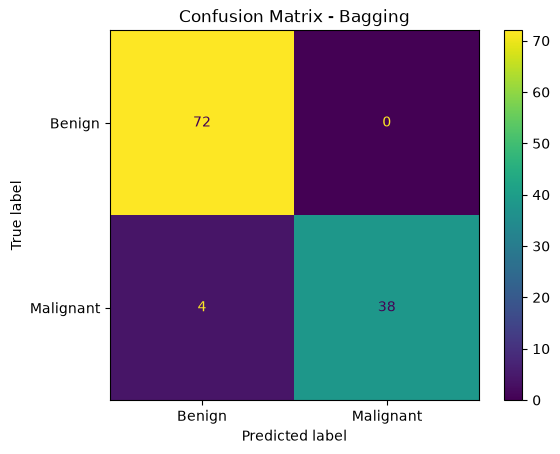


Confusion Matrix - Boosting
[[72  0]
 [ 4 38]]


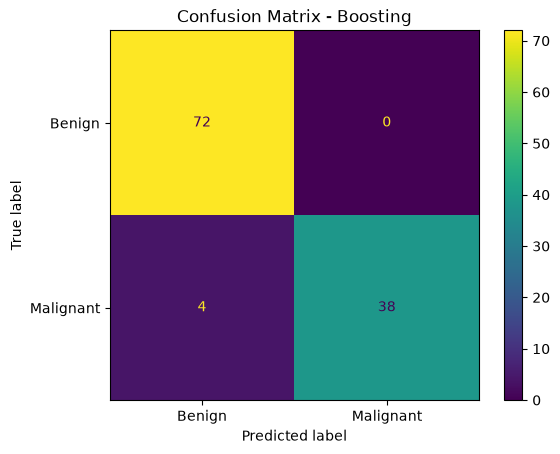


Confusion Matrix - Stacking
[[72  0]
 [ 3 39]]


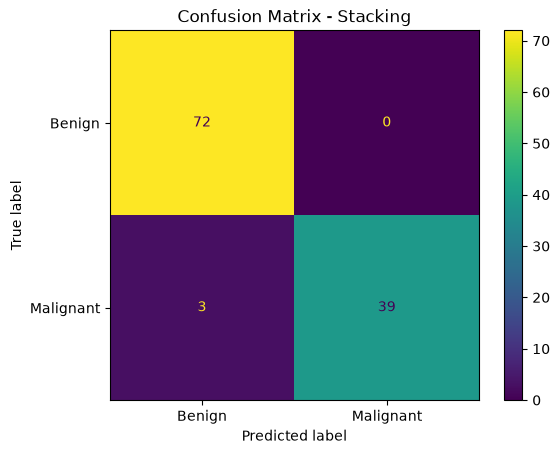

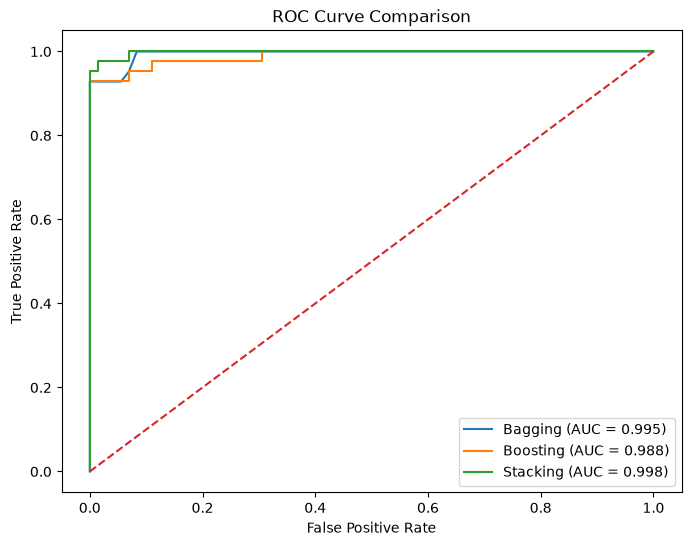


AUC Scores
Bagging: 0.9949
Boosting: 0.9884
Stacking: 0.9980


In [10]:
# ==============================
# CELL 7: CONFUSION MATRIX + ROC + AUC
# ==============================

# Store predictions and probabilities
predictions = {}
probabilities = {}

for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)
    predictions[name] = y_pred

    # Probability of positive class
    y_prob = model.predict_proba(X_test)[:, 1]
    probabilities[name] = y_prob


# ==============================
# 1. CONFUSION MATRICES
# ==============================

for name in models:

    print("\nConfusion Matrix -", name)

    cm = confusion_matrix(
        y_test,
        predictions[name]
    )

    print(cm)

    # Display confusion matrix
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Benign", "Malignant"]
    ).plot()

    plt.title(f"Confusion Matrix - {name}")
    plt.show()


# ==============================
# 2. ROC CURVES
# ==============================

plt.figure(figsize=(8, 6))

for name in models:

    # Calculate FPR and TPR
    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities[name]
    )

    # Calculate AUC
    auc_score = roc_auc_score(
        y_test,
        probabilities[name]
    )

    # Plot ROC curve
    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )


# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


# ==============================
# 3. PRINT AUC VALUES
# ==============================

print("\nAUC Scores")
print("====================")

for name in models:

    auc_score = roc_auc_score(
        y_test,
        probabilities[name]
    )

    print(f"{name}: {auc_score:.4f}")